In [1]:

import gc
import time
import urllib

# import jax
import torch
import torch.nn.parallel
import torch.distributed.checkpoint

import pi.data

# import pi.models.pi0_config
import pi.models.pi_config
import pi.models.pi_config as pi_config
import pi.training.optimizer as _optimizer
import pi.models_pytorch.pi0_pytorch
from pi.models.model import Observation
from pi.training.config import TrainConfig, DatasetConfig
from pi.inference_buffer_v2 import InferenceBufferV2
from pi.services.ws_json_api import JSONWebSocketAPIServer

🚨 `adarms_cond` is part of GemmaModel.forward's signature, but not documented. Make sure to add it to the docstring of the function in /home/jovyan/Pi/src/pi/models/gemma_/modeling_gemma.py.
🚨 `adarms_cond` is part of GemmaForCausalLM.forward's signature, but not documented. Make sure to add it to the docstring of the function in /home/jovyan/Pi/src/pi/models/gemma_/modeling_gemma.py.
🚨 `adarms_cond` is part of GemmaForSequenceClassification.forward's signature, but not documented. Make sure to add it to the docstring of the function in /home/jovyan/Pi/src/pi/models/gemma_/modeling_gemma.py.
🚨 `adarms_cond` is part of GemmaForTokenClassification.forward's signature, but not documented. Make sure to add it to the docstring of the function in /home/jovyan/Pi/src/pi/models/gemma_/modeling_gemma.py.
🚨 `return_loss` is part of SiglipModel.forward's signature, but not documented. Make sure to add it to the docstring of the function in /home/jovyan/Pi/src/pi/models/siglip/modeling_siglip.py.


In [2]:
HORIZON = 30
NUM_STEPS = 40
DISCRETE_STATE_INPUT = True

config = TrainConfig(
    name="pi05_airbot",
    model=pi_config.PiConfig(pi05=True, action_horizon=HORIZON, discrete_state_input=DISCRETE_STATE_INPUT),
    data=DatasetConfig(
        repo_id="/home/jovyan/data/1020_laundry_id_2_100sample_merge",
        asset_id="airbot",
        apply_delta_transform=True,
        use_quantile_norm=True,
        action_sequence_keys=("action",),  # Airbot dataset uses "action" not "actions"
        state_sequence_keys=("observation.state",),
    ),
    batch_size=1,
    lr_schedule=_optimizer.CosineDecaySchedule(
        warmup_steps=5_000,
        peak_lr=5e-5,
        decay_steps=500_000,
        decay_lr=5e-5,
    ),
    optimizer=_optimizer.AdamW(clip_gradient_norm=1.0),
    ema_decay=0.999,
    pytorch_weight_path=None,
    overwrite=True,   # <-- 加这一行
)


def tree_map_to_device(item, target_device):
    """Recursively move tree structures to target device."""
    if isinstance(item, dict):
        return {key: tree_map_to_device(value, target_device) for key, value in item.items()}
    elif isinstance(item, (list, tuple)):
        result = [tree_map_to_device(value, target_device) for value in item]
        return type(item)(result)
    elif hasattr(item, "__dict__") and not hasattr(item, "to"):
        # Handle custom objects like frozen dataclasses (e.g., Observation)
        import dataclasses

        if dataclasses.is_dataclass(item):
            # For dataclasses, use dataclasses.replace to create a new instance
            new_attrs = {}
            for field in dataclasses.fields(item):
                attr_value = getattr(item, field.name)
                new_attrs[field.name] = tree_map_to_device(attr_value, target_device)
            return dataclasses.replace(item, **new_attrs)
        else:
            # Handle other custom objects by recursively processing their attributes
            new_attrs = {}
            for attr_name, attr_value in item.__dict__.items():
                new_attrs[attr_name] = tree_map_to_device(attr_value, target_device)

            # Create a new instance with updated attributes
            new_item = type(item).__new__(type(item))
            for attr_name, attr_value in new_attrs.items():
                setattr(new_item, attr_name, attr_value)
            return new_item
    else:
        # Leaf node: move to device if it's a tensor
        return item.to(target_device) if hasattr(item, "to") else item

In [3]:
import gc
import sys
import os
sys.path.append("/home/jovyan/Pi/scripts/deployment")
from normalizer import MetadataNormalizingPlanner
ckpt_path = "/data/robot/checkpoints/test0602"
# ckpt_path = "//home/admin01/shuqi/model_ckpts/mixed_211"

model_name = "_".join(ckpt_path.split("/")[-2:])

with torch.device("cuda:0"):
    model = pi.models_pytorch.pi0_pytorch.PI0Pytorch(config.model)
torch.distributed.checkpoint.load(model.state_dict(), checkpoint_id=ckpt_path, planner=MetadataNormalizingPlanner())
gc.collect()
torch.cuda.empty_cache()
gc.collect()

model_name

/home/jovyan/Pi/.pixi/envs/default/lib/python3.12/site-packages/torch/distributed/checkpoint/utils.py:483: UserWarning: torch.distributed is disabled, unavailable or uninitialized, assuming the intent is to load in a single process.
  return func(*args, **kwargs)


'checkpoints_test0602'

In [4]:
URL = "http://127.0.0.1:5082"


def get_buffer(url):
    def _http_get(url: str, *, timeout: float = 2.0) -> tuple[int, bytes]:
        req = urllib.request.Request(url, method="GET")
        try:
            with urllib.request.urlopen(req, timeout=timeout) as resp:
                return resp.getcode(), resp.read()
        except urllib.error.HTTPError as e:
            return e.code, e.read() if e.fp else b""

    health = f"{URL}/api/v1/healthz"
    code, body = _http_get(health, timeout=2.0)
    if code == 200:
        print(f"HEALTHZ 200 {body.decode('utf-8', 'ignore')}")
    print(f"HEALTHZ {code} waiting...")
    time.sleep(0.2)

    # Fetch base64 payload once
    b64_url = f"{URL}/api/v1/infer-buffer/base64"
    code, body = _http_get(b64_url, timeout=5.0)
    if code != 200:
        print(f"FAIL GET_BASE64 status={code}")
    payload_b64 = body.decode("ascii").strip()
    print(f"GET_BASE64 {code} len={len(payload_b64)}")
    buffer = InferenceBufferV2.from_base64(payload_b64)
    return buffer


action_server = JSONWebSocketAPIServer(host="0.0.0.0", port=18081)
action_server.start()

In [5]:
# Load norm_stats from assets directory
# norm_stats = config.data.load_norm_stats(config.assets_dirs)
import pi.shared.normalize as _normalize
norm_stat_path = "/home/jovyan/Pi/assets/pi05_airbot/airbot"
# norm_stat_path = "/home/admin01/shuqi/model_ckpts/mixed_11/airbot_pants"
# norm_stat_path = "/home/admin01/shuqi/model_ckpts/future-state-step230k/airbot_sleeves"
norm_stats = _normalize.load(norm_stat_path)
print(norm_stats)


{'state': NormStats(mean=array([-0.19134371, -1.31641114,  0.87128019,  0.7649098 , -0.7020418 ,
       -1.26649344,  0.02383951,  0.12134645, -1.38863134,  1.03149998,
        2.2456131 , -0.75811362, -1.78148043,  0.03463468]), std=array([0.20286442, 0.66931319, 0.51473039, 0.31841293, 0.23361804,
       0.29184663, 0.03130514, 0.1984994 , 0.64068383, 0.5928418 ,
       0.58187854, 0.40923381, 0.59459144, 0.03376706]), q01=array([-6.02922082e-01, -2.08876944e+00, -8.44968334e-02,  9.55596268e-02,
       -1.12287331e+00, -1.81982911e+00, -7.62026320e-05, -3.43308926e-01,
       -2.12500954e+00, -8.10635537e-02, -8.04341197e-01, -1.35748076e+00,
       -2.45727468e+00, -1.08815686e-04]), q99=array([ 0.31948578,  0.17338064,  1.71225297,  1.50358582, -0.09784847,
       -0.53959715,  0.06983146,  0.5735485 ,  0.1722362 ,  1.98882282,
        2.76283669,  0.86537731,  1.50816357,  0.07075068])), 'actions': NormStats(mean=array([-0.1907676 , -1.31781936,  0.87205786,  0.75821656, -0.70347

In [6]:
dataloader = pi.data.SimpleLeRobotLoader(
    None,
    repo_id=config.data.repo_id,
    action_sequence_keys=list(config.data.action_sequence_keys),
    state_sequence_keys=list(config.data.state_sequence_keys),
    norm_stats=norm_stats,
    use_quantile_norm=config.data.use_quantile_norm,
    policy_name=config.name,
    batch_size=config.batch_size,
    action_horizon=config.model.action_horizon,
    action_dim=config.model.action_dim,
    max_token_len=config.model.max_token_len,
    discrete_state_input=DISCRETE_STATE_INPUT,
    apply_delta_transform=config.data.apply_delta_transform,
)
data_iter = iter(dataloader)
sample_data = next(data_iter)
sample_data.keys()

Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

dict_keys(['state', 'image', 'image_mask', 'actions', 'tokenized_prompt', 'tokenized_prompt_mask'])

In [7]:

prompt = dataloader.dataset[0]["task"]
tokenized_prompt = sample_data["tokenized_prompt"]
tokenized_prompt_mask = sample_data["tokenized_prompt_mask"]
image_mask = sample_data["image_mask"]
print(tokenized_prompt.shape, tokenized_prompt_mask.shape)

data_template = {
    "prompt": prompt,
    "tokenized_prompt": tokenized_prompt,
    "tokenized_prompt_mask": tokenized_prompt_mask,
    "image_mask": image_mask,
    "image": {},
}

sample_data["image"].keys()

torch.Size([1, 200]) torch.Size([1, 200])


dict_keys(['base_0_rgb', 'left_wrist_0_rgb', 'right_wrist_0_rgb'])

In [8]:

data = tree_map_to_device(data_template, "cuda:0")
data.keys()

dict_keys(['prompt', 'tokenized_prompt', 'tokenized_prompt_mask', 'image_mask', 'image'])

In [9]:
print(1)

1


In [10]:

buffer = get_buffer(URL)
buffer.images.keys()

HEALTHZ 200 {"status":"ok"}

HEALTHZ 200 waiting...
GET_BASE64 200 len=1344


dict_keys(['left', 'mid', 'right'])

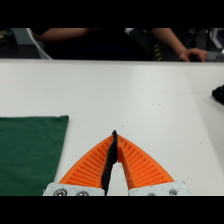

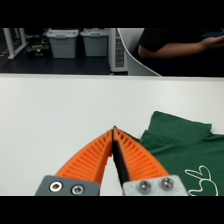

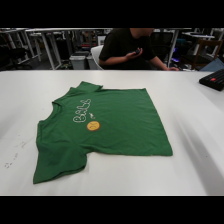

In [11]:

from PIL import Image
from IPython.display import display

with buffer.hold_lock():
    right = buffer.images["right"].cpu().numpy()
    img = Image.fromarray(right)
    display(img)
    left = buffer.images["left"].cpu().numpy()
    img = Image.fromarray(left)
    display(img)
    mid = buffer.images["mid"].cpu().numpy()
    img = Image.fromarray(mid)
    display(img)

In [12]:

import numpy as np

from pi.data import _normalize_array, _tokenize_prompt


def _pad_state_actions(state: np.ndarray, target_dim: int) -> dict:
    def _pad_last_dim(array: np.ndarray, target_dim: int) -> np.ndarray:
        array = np.asarray(array, dtype=np.float64)
        if array.shape[-1] >= target_dim:
            return array
        pad_width = [(0, 0)] * array.ndim
        pad_width[-1] = (0, target_dim - array.shape[-1])
        return np.pad(array, pad_width, constant_values=0.0)

    return _pad_last_dim(state, target_dim)


def update_data(data: dict):
    """更新推理数据，包括图像和状态。

    返回原始未归一化的 state，用于后续的 delta → absolute 转换。
    这与训练逻辑保持一致：训练时在归一化前应用 delta transform。
    """
    stats = dataloader.norm_stats
    with buffer.hold_lock():
        data["image"]["base_0_rgb"] = buffer.images["mid"].unsqueeze(0).clone()
        data["image"]["left_wrist_0_rgb"] = buffer.images["left"].unsqueeze(0).clone()
        data["image"]["right_wrist_0_rgb"] = buffer.images["right"].unsqueeze(0).clone()

    # 获取当前机器人状态
    state = action_server.recv_state()
    left_state = state["left_arm"]["positions"]
    right_state = state["right_arm"]["positions"]
    state_array = np.array(left_state + right_state, dtype=np.float32)

    # 保存原始 state（用于 delta → absolute 转换）
    original_state = state_array.copy()
    original_time = state["timestamp/ms"]

    # 归一化 state（用于模型输入）
    state_array = _normalize_array(state_array, stats["state"], dataloader.use_quantile_norm)
    data["state"] = state_array

    # 重新tokenize
    enc_res = _tokenize_prompt(data=data, tokenizer=dataloader.tokenizer, discrete_state_input=DISCRETE_STATE_INPUT)
    data["tokenized_prompt"] = torch.from_numpy(enc_res["tokenized_prompt"]).unsqueeze(0).to("cuda:0")
    data["tokenized_prompt_mask"] = torch.from_numpy(enc_res["tokenized_prompt_mask"]).unsqueeze(0).to("cuda:0")

    state_array = _pad_state_actions(state_array, target_dim=32)
    state_tensor = torch.from_numpy(state_array).unsqueeze(0).to("cuda:0")
    data["state"] = state_tensor

    # 返回原始 state，用于后续的 absolute actions 转换
    return data, original_state, original_time

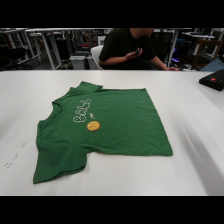

In [13]:

noise = model.sample_noise((1, HORIZON, 32), device="cuda:0")
sample_actions = torch.compile(model.sample_actions, mode="max-autotune")
# sample_actions = model.sample_actions


def display_image(where="mid"):
    with buffer.hold_lock():
        mid = buffer.images[where].cpu().numpy()
        img = Image.fromarray(mid)
        display(img)


display_image()

In [14]:


import pi
import pi.transforms


def _unnormalize_quantile(x, stats):
    assert stats.q01 is not None
    assert stats.q99 is not None
    q01, q99 = stats.q01, stats.q99
    if (dim := q01.shape[-1]) < x.shape[-1]:
        return np.concatenate([(x[..., :dim] + 1.0) / 2.0 * (q99 - q01 + 1e-6) + q01, x[..., dim:]], axis=-1)
    return (x + 1.0) / 2.0 * (q99 - q01 + 1e-6) + q01


def _unnormalize_no_quantile(x, stats):
    mean = pi.transforms.pad_to_dim(stats.mean, x.shape[-1], axis=-1, value=0.0)
    std = pi.transforms.pad_to_dim(stats.std, x.shape[-1], axis=-1, value=1.0)
    return x * (std + 1e-6) + mean


def _make_bool_mask(*dims: int) -> tuple[bool, ...]:
    """Make a boolean mask for the given dimensions.

    Example:
        _make_bool_mask(2, -2, 2) == (True, True, False, False, True, True)
        _make_bool_mask(2, 0, 2) == (True, True, True, True)

    Args:
        dims: The dimensions to make the mask for.

    Returns:
        A tuple of booleans.
    """
    result = []
    for dim in dims:
        if dim > 0:
            result.extend([True] * dim)
        else:
            result.extend([False] * (-dim))
    return tuple(result)


def _apply_absolute_actions(actions: np.ndarray, current_state: np.ndarray, mask: tuple[bool, ...]) -> np.ndarray:
    """将 delta actions 转换回 absolute actions。

    这是 transforms.AbsoluteActions 的实现，用于推理时将模型预测的 delta 转回绝对动作。

    Args:
        actions: 模型预测的 delta actions，shape: (horizon, action_dim)
        current_state: 当前机器人状态（原始未归一化的值），shape: (state_dim,)
        mask: 布尔掩码，指定哪些维度需要从 delta 转换为 absolute

    Returns:
        absolute actions，shape: (horizon, action_dim)
    """
    mask_array = np.asarray(mask)
    dims = mask_array.shape[-1]
    # delta → absolute: actions = actions + state (for masked dims)
    actions[..., :dims] += np.expand_dims(np.where(mask_array, current_state[:dims], 0), axis=-2)
    return actions


def process_action(action: torch.Tensor, original_state: np.ndarray, original_time: float) -> dict:
    """处理模型预测的动作，转换为机器人可执行的格式。

    Args:
        action: 模型预测的动作张量，shape: (1, horizon, action_dim)
        original_state: 原始未归一化的 state，shape: (state_dim,)
                       用于 delta → absolute 转换

    Returns:
        action_msg: 动作消息字典
    """
    stats = dataloader.norm_stats["actions"]
    action = action[0, :60, :14].cpu().numpy()  # AirbotOutputs: 只取前14维
    action = _unnormalize_quantile(action, stats)  # 反归一化
    # action = _unnormalize_no_quantile(action, stats)  # 反归一化

    # 如果训练时使用了 extra_delta_transform，需要将 delta 转回 absolute
    # 这与训练逻辑保持一致：训练时在归一化前应用 delta transform
    # if getattr(config.data, "extra_delta_transform", True):
    # Airbot 的 mask: (6, -1, 6, -1) = 前6个关节 + 1个gripper + 后6个关节 + 1个gripper
    delta_action_mask = _make_bool_mask(6, -1, 6, -1)
    action = _apply_absolute_actions(action, original_state, delta_action_mask)

    left_arm = action[0:, :7].tolist()
    right_arm = action[0:, 7:14].tolist()
    action_msg = {
        "control_mode": "joint",
        "timestamp/ms": original_time,
        "delta/ms": 50,
        "left_arm": {"actions": left_arm},
        "right_arm": {"actions": right_arm},
        "send_time": time.time(),
    }
    return action_msg


state = action_server.recv_state()

In [15]:


def warmup():
    _, original_state, _ = update_data(data)
    obs = Observation.from_dict(data)
    pred_actions = sample_actions(device="cuda:0", observation=obs, noise=noise, num_steps=NUM_STEPS)


from tqdm.auto import tqdm

print(state)
for _ in tqdm(range(10)):
    warmup()

{'timestamp/ms': 1780402656917.0396, 'left_arm': {'positions': [0.000572213320992887, -0.000572213320992887, -0.01773861236870289, 0.005531395319849253, -0.007438773289322853, -0.005912871100008488, -6.31283275165026e-05], 'velocities': [-0.004395604599267244, -0.004395604599267244, -0.004395604599267244, 0.007326007355004549, -0.007326007355004549, -0.03663003817200661, -0.007326007355004549]}, 'right_arm': {'positions': [0.000572213320992887, 0.00019073777366429567, -0.06771191209554672, -0.005149920005351305, 0.004005493130534887, 0.007438773289322853, -0.00023180108786112485], 'velocities': [-0.004395604599267244, -0.004395604599267244, -0.004395604599267244, -0.007326007355004549, 0.007326007355004549, -0.007326007355004549, -0.021978022530674934]}, 'timestamp': 1780402656.917403}


  0%|          | 0/10 [00:00<?, ?it/s]

/home/jovyan/Pi/.pixi/envs/default/lib/python3.12/site-packages/torch/_dynamo/variables/functions.py:2082: UserWarning: Dynamo does not know how to trace the builtin `builtins.__build_class__.` This function is either a Python builtin (e.g. _warnings.warn) or a third-party C/C++ Python extension (perhaps created with pybind).
If it is a Python builtin, please file an issue on GitHub so the PyTorch team can add support for it and see the next case for a workaround.
If it is a third-party C/C++ Python extension, please either wrap it into a PyTorch-understood custom operator (see https://pytorch.org/tutorials/advanced/custom_ops_landing_page.html for more details) or, if it is traceable, use `torch.compiler.allow_in_graph`.
  torch._dynamo.utils.warn_once(explanation + "\n" + "\n".join(hints))


In [16]:

# %%timeit
# warmup()

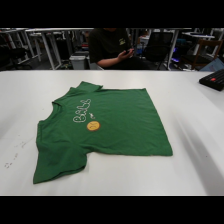

{'timestamp/ms': 1780402678429.0344,
 'left_arm': {'positions': [0.000572213320992887,
   -0.000572213320992887,
   -0.01773861236870289,
   0.005531395319849253,
   -0.007057297509163618,
   -0.005531395319849253,
   -6.31283275165026e-05],
  'velocities': [-0.004395604599267244,
   -0.004395604599267244,
   -0.004395604599267244,
   0.007326007355004549,
   0.007326007355004549,
   -0.007326007355004549,
   -0.007326007355004549]},
 'right_arm': {'positions': [0.000572213320992887,
   0.00019073777366429567,
   -0.06771191209554672,
   -0.005531395319849253,
   0.0036240178160369396,
   0.0078202486038208,
   -0.00023180108786112485],
  'velocities': [-0.004395604599267244,
   -0.004395604599267244,
   -0.004395604599267244,
   -0.021978022530674934,
   -0.007326007355004549,
   0.007326007355004549,
   -0.007326007355004549]},
 'timestamp': 1780402678.4294014}

In [17]:

state = action_server.recv_state()
display_image()
warmup()
state

In [18]:

action = dataloader.dataset[0]["action"].numpy()[0]
action_msg = {
    "control_mode": "joint",
    "timestamp/ms": time.time() * 1000,
    "delta/ms": 50,
    "left_arm": {"actions": [action[:7].tolist()] * 10},
    "right_arm": {"actions": [action[7:].tolist()] * 10},
    # "left_arm": {"actions": [[0., 0., 0., 1.55, 0., -1.55, 0.072]] * 10},
    # "right_arm": {"actions": [[0., 0., 0., 1.55, 0., -1.55, 0.072]] * 10},
    "send_time": time.time(),
}
action_server.send_action(action_msg)

res = []


def get_action(data: dict):
    start = time.time()
    noise = model.sample_noise((1, HORIZON, 32), device="cuda:0")
    _, original_state, original_time = update_data(data)
    obs = Observation.from_dict(data)
    pred_actions = sample_actions(device="cuda:0", observation=obs, noise=noise, num_steps=NUM_STEPS)
    action_msg = process_action(pred_actions, original_state, original_time)
    action_server.send_action(action_msg)
    end = time.time()
    # time.sleep(0.4)
    states = action_server.recv_state()
    positions = states["left_arm"]["positions"] + states["right_arm"]["positions"]
    velocities = states["left_arm"]["velocities"] + states["right_arm"]["velocities"]
    action_msg["states"] = positions
    action_msg["velocities"] = velocities
    res.append(action_msg)
    print(f"INFER {end - start:.3f}s")

In [19]:
get_action(data)

INFER 0.212s


In [20]:

while True:
    get_action(data)
    # time.sleep(2)

INFER 0.081s
INFER 0.080s
INFER 0.080s
INFER 0.080s


KeyboardInterrupt: 